# Aprendizado profundo - Cartas Clash royale


In [42]:
import os
import time
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

In [43]:
INPUT_DIR = './Assets_Raw'
OUTPUT_DIR = './Assets_Expanded'
COPIAS_POR_CARTA = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define as transformações (Mutações)
augmenter = T.Compose([
    T.RandomRotation(degrees=20),        # Gira um pouco
    T.ColorJitter(brightness=0.3, contrast=0.3), # Muda brilho/contraste
    T.RandomPerspective(distortion_scale=0.2, p=0.5), # Entorta um pouco
    T.RandomResizedCrop(size=(250, 200), scale=(0.8, 1.0)) # Zoom aleatório
])

print(f"Lendo imagens de: {INPUT_DIR}")
print(f"Salvando versões em: {OUTPUT_DIR}")
print("Gerando clones...")

arquivos = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg'))]

count = 0
for arq in arquivos:
    caminho_orig = os.path.join(INPUT_DIR, arq)
    try:
        # Abre a original
        img = Image.open(caminho_orig).convert('RGB')

        # Salva a original na pasta nova também
        img.save(os.path.join(OUTPUT_DIR, arq))

        # Cria as cópias
        nome_base = os.path.splitext(arq)[0]
        for i in range(COPIAS_POR_CARTA):
            img_aug = augmenter(img)
            novo_nome = f"{nome_base}_v{i}.jpg"
            img_aug.save(os.path.join(OUTPUT_DIR, novo_nome))

        count += 1
    except Exception as e:
        print(f"Erro em {arq}: {e}")

print(f"\n--- CONCLUÍDO! ---")
print(f"Processamos {count} cartas.")
print(f"Total estimado de imagens agora: {count * (COPIAS_POR_CARTA + 1)}")

Lendo imagens de: ./Assets_Raw
Salvando versões em: ./Assets_Expanded
Gerando clones...

--- CONCLUÍDO! ---
Processamos 291 cartas.
Total estimado de imagens agora: 1746


In [44]:
# --- CLASSE DO DATASET ---
# Essa classe ensina o PyTorch a ler UMA imagem do CSV
class ClashRoyaleDataset(Dataset):
    def __init__(self, df, transform=None, class_to_idx=None):
        self.df = df
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Pega a linha do CSV
        row = self.df.iloc[idx]

        # Carrega a imagem
        img_path = row['caminho_completo']
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Caso alguma imagem esteja corrompida, cria uma preta (evita crash)
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        # Aplica as transformações (Resize, ToTensor, etc)
        if self.transform:
            image = self.transform(image)

        # Converte o nome da carta (String) para número (Int)
        label_str = row['label']
        label = self.class_to_idx[label_str]

        return image, label

# --- FUNÇÃO PARA PREPARAR TUDO ---
def preparar_dataloaders():
    # 1. Lê o CSV
    df = pd.read_csv(NOVO_CSV_PATH)

    # 2. Cria o dicionário de classes (Ex: {'Archer': 0, 'Giant': 1})
    classes = sorted(df['label'].unique())
    class_to_idx = {nome: i for i, nome in enumerate(classes)}
    num_classes = len(classes)

    print(f"Classes encontradas: {classes}")

    # 3. Separa Treino (80%) e Validação (20%)
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

    # 4. Define as transformações padrão da ResNet
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((224, 224)), # ResNet precisa de 224x224
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'val': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

    # 5. Cria os objetos Dataset
    train_dataset = ClashRoyaleDataset(train_df, transform=data_transforms['train'], class_to_idx=class_to_idx)
    val_dataset = ClashRoyaleDataset(val_df, transform=data_transforms['val'], class_to_idx=class_to_idx)

    # 6. Cria os DataLoaders (que entregam os batches)
    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
        'val': DataLoader(val_dataset, batch_size=32, shuffle=False)
    }

    return dataloaders, classes, num_classes

In [45]:
# --- FUNÇÃO DE TREINO (O MOTOR DO MODELO) ---
def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()

    # Guarda o melhor modelo encontrado
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dicionário para guardar histórico e plotar gráficos depois
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # Progress bar para as épocas
    epoch_pbar = tqdm(range(num_epochs), desc='Training Progress', unit='epoch')
    
    for epoch in epoch_pbar:
        epoch_pbar.set_description(f'Época {epoch+1}/{num_epochs}')

        # Cada época tem fase de treino e validação
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Modo de treino (atualiza pesos)
            else:
                model.eval()   # Modo de avaliação (congela pesos)

            running_loss = 0.0
            running_corrects = 0

            # Progress bar para os batches
            batch_pbar = tqdm(dataloaders[phase], 
                            desc=f'{phase.capitalize()}', 
                            leave=False,
                            unit='batch')

            # Itera sobre os dados (batches)
            for inputs, labels in batch_pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zera os gradientes
                optimizer.zero_grad()

                # Forward (passa a imagem pelo modelo)
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward (aprende) apenas no treino
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Estatísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Atualiza a barra de progresso com loss atual
                batch_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            # Salva no histórico
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                epoch_pbar.set_postfix({
                    'train_loss': f'{epoch_loss:.4f}',
                    'train_acc': f'{epoch_acc:.4f}'
                })
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                epoch_pbar.set_postfix({
                    'train_loss': f'{history["train_loss"][-1]:.4f}',
                    'train_acc': f'{history["train_acc"][-1]:.4f}',
                    'val_loss': f'{epoch_loss:.4f}',
                    'val_acc': f'{epoch_acc:.4f}'
                })

            # Se for o melhor modelo até agora, salva
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since

    # Carrega os melhores pesos no modelo final
    model.load_state_dict(best_model_wts)
    return model, history

# --- FUNÇÃO PARA PLOTAR GRÁFICOS ---
def plotar_graficos(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Gráfico de Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Treino Acurácia')
    plt.plot(epochs_range, val_acc, label='Validação Acurácia')
    plt.legend(loc='lower right')
    plt.title('Acurácia de Treino e Validação')

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Treino Loss')
    plt.plot(epochs_range, val_loss, label='Validação Loss')
    plt.legend(loc='upper right')
    plt.title('Perda (Loss) de Treino e Validação')

    plt.show()

Novo CSV gerado com 1746 imagens!
Caminho: ./dataset_expandido.csv
Classes encontradas: ['Archer Card Frame Alpha', 'Archer Queen', 'Arrows', 'Baby Dragon', 'Baby Dragon Evolution Card', 'Baby Dragon Evolution Card Frame', 'Baby Dragon Evolution Shard', 'Baby Dragon Evolution Shard Transparent', 'Baby Draqgon Evolution Card Frame Gem', 'Balloon', 'Barbarian Barrel', 'Bats Evolution Card', 'Bats Evolution Frame Card', 'Boss Bandit Card', 'Boss Bandit Card Frame Alpha', 'Card Archer Evolution', 'Card Bandit', 'Card Barbarian Hut', 'Card Barbarians', 'Card Barbarians Evolution', 'Card Bats', 'Card Battle Healer', 'Card Battle Ram', 'Card Battle Ram Evolution', 'Card Battle Ram Evolution 01', 'Card Berserker', 'Card Berserker 01', 'Card Bomb Tower', 'Card Bomber', 'Card Bomber Evolution', 'Card Bomber Evolution Frame', 'Card Bowler', 'Card Cannon', 'Card Cannon Cart', 'Card Cannon Evolution', 'Card Cannon Evolution 01', 'Card Cannon Evolution Frame', 'Card Cannoneer', 'Card Cannoneer Tower

Época 15/15: 100%|██████████| 15/15 [12:09<00:00, 48.65s/epoch, train_loss=0.0639, train_acc=1.0000, val_loss=0.2923, val_acc=0.9314]


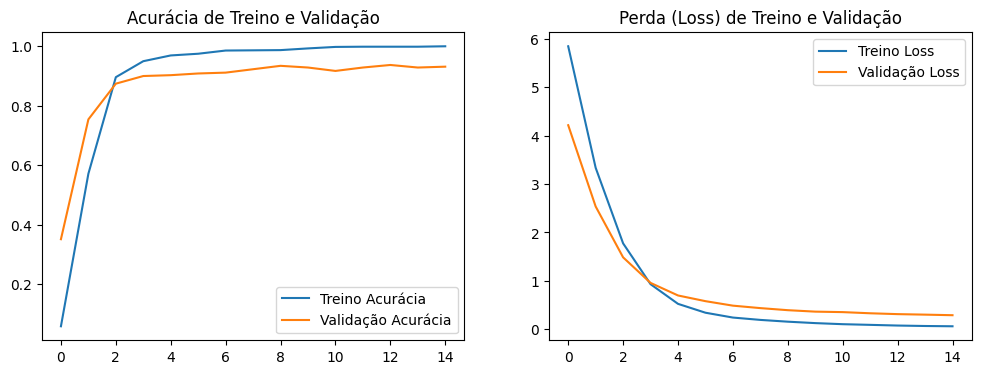

In [46]:
# --- NOVOS CAMINHOS ---
NOVO_IMG_DIR = './Assets_Expanded'
NOVO_CSV_PATH = './dataset_expandido.csv'

import pandas as pd

arquivos = os.listdir(NOVO_IMG_DIR)
dados = []

for arq in arquivos:
    if arq.lower().endswith(('.png', '.jpg', '.jpeg')):
        # O truque: O label é o nome original (sem o _v1, _v2 etc)
        # Ex: "Archer_v3.jpg" -> Label: "Archer"
        nome_limpo = arq.split('_v')[0].replace('.png', '').replace('.jpg', '')
        label = nome_limpo.replace('-', ' ').replace('_', ' ').title()

        dados.append({
            'nome_arquivo': arq,
            'label': label,
            'caminho_completo': os.path.join(NOVO_IMG_DIR, arq)
        })

df = pd.DataFrame(dados)
df.to_csv(NOVO_CSV_PATH, index=False)
print(f"Novo CSV gerado com {len(df)} imagens!")
print(f"Caminho: {NOVO_CSV_PATH}")

# --- 2. Atualiza as variáveis globais para o Treino ---
# Isso sobrescreve as variáveis do código anterior
CSV_PATH = NOVO_CSV_PATH
IMG_DIR = NOVO_IMG_DIR

# 3. Recarrega os Dataloaders
# (Certifique-se de que a função 'preparar_dataloaders' e a classe 'Dataset' já estão definidas na memória)
dataloaders, class_names, num_classes = preparar_dataloaders()

# 4. Reseta e Re-treina o modelo
# (Certifique-se de que a função 'train_model' já está definida)
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# TREINA!
modelo_treinado, historico = train_model(model, criterion, optimizer, num_epochs=15)

# PLOTA!
plotar_graficos(historico)


(np.float64(-0.5), np.float64(522.5), np.float64(138.5), np.float64(-0.5))

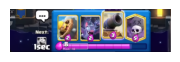

In [47]:
img = Image.open('image.png')
img_array = np.array(img)
height, width = img_array.shape[:2]

# pega 20%
bottom_25_start = int(height * 0.80)
bottom_25 = img_array[bottom_25_start:, :]

plt.figure(figsize=(12, 4))
plt.subplot(1, 5, 1)
plt.imshow(bottom_25)
plt.axis('off')
    

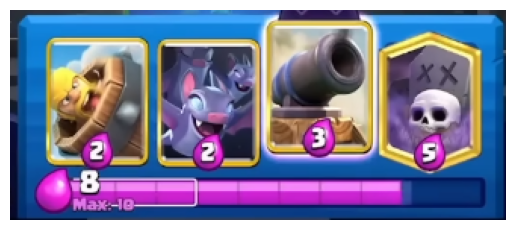

In [48]:
card_deck = bottom_25
deck_width = card_deck.shape[1]
#better sizing
start = int(deck_width // 4)
end = int(deck_width - (deck_width // 8))
rightmost_part = card_deck[:, start:end]
plt.figure()
plt.imshow(rightmost_part)
plt.axis('off')
plt.show()

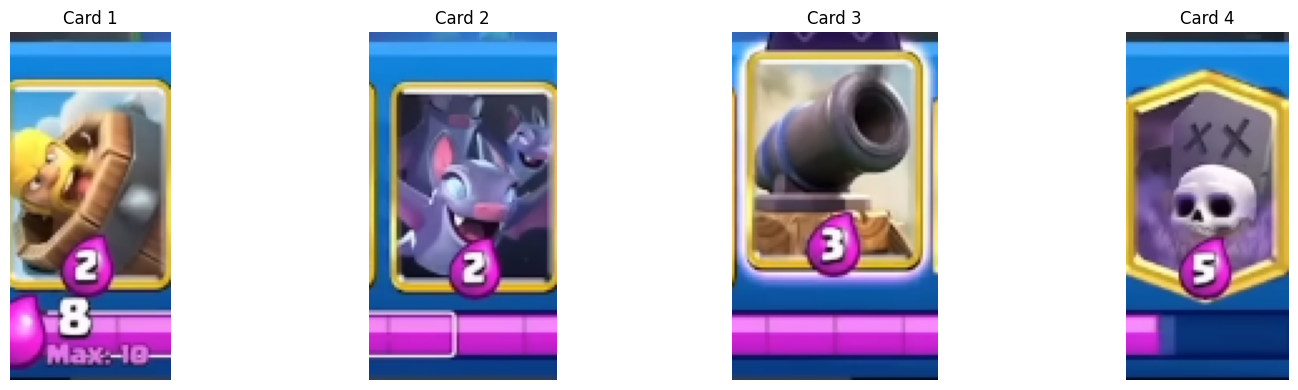

In [49]:
start = int(deck_width // 4)
end = int(deck_width - (deck_width // 8))
rightmost_part = card_deck[:, start:end]

# Get the width of the rightmost part
rightmost_width = rightmost_part.shape[1]

# Split into 4 equal parts (25% each)
card_width = rightmost_width // 4
cards = []

plt.figure(figsize=(16, 4))

for i in range(4):
    current_width = card_width
    if i == 0: 
        current_width += 15
    start_x = i * current_width
    end_x = (i + 1) * current_width if i < 3 else rightmost_width
    card = rightmost_part[:, start_x:end_x]
    
    # Get the middle row
    middle_row = card.shape[0] // 2
    middle_pixels = card[middle_row, :, :]
    
    # Detect yellow pixels in middle row (high R and G, low B)
    yellow_mask = (middle_pixels[:, 0] > 180) & (middle_pixels[:, 1] > 180) & (middle_pixels[:, 2] < 150)
    
    # Find leftmost and rightmost yellow pixels in middle row
    yellow_cols = np.where(yellow_mask)[0]
    
    if len(yellow_cols) > 0:
        left_edge = yellow_cols[0]
        right_edge = yellow_cols[-1]
        
        # Crop card to yellow boundaries
        card = card[:, left_edge:right_edge+1]
    
    cards.append(card)
    
    # Display each card
    plt.subplot(1, 4, i + 1)
    plt.imshow(card)
    plt.axis('off')
    plt.title(f'Card {i+1}')

plt.tight_layout()
plt.show()

In [50]:
def predict_card(image_path_or_array, model, class_names, device):
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    

    image = Image.fromarray(image_path_or_array).convert('RGB')
    
    # arrumar para o modelo
    input_tensor = preprocess(image)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
    
    predicted_class = class_names[predicted_idx.item()]
    
    return predicted_class, confidence.item()

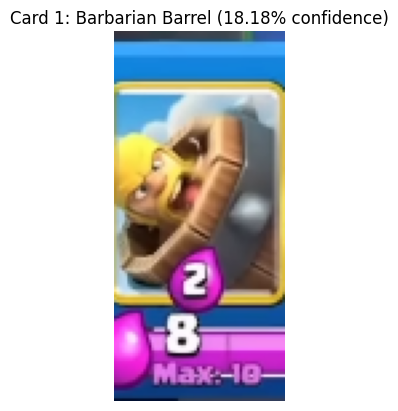

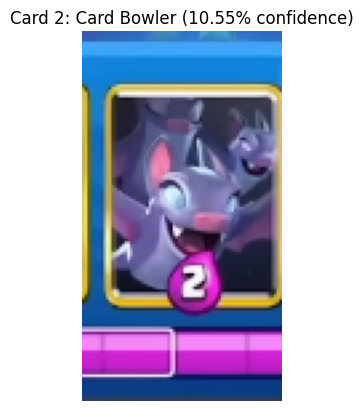

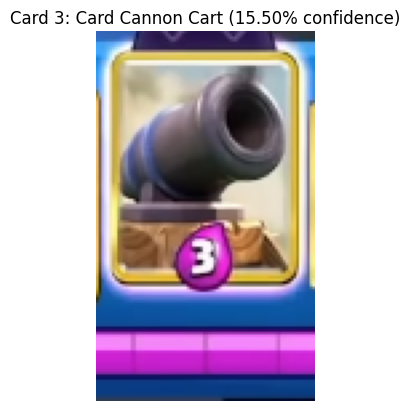

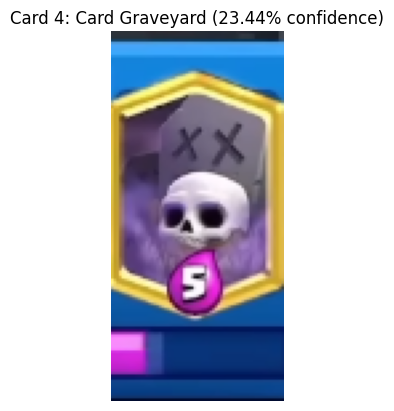

In [51]:
for i in range(4):
    card = cards[i]
    predicted_class, confidence = predict_card(card, modelo_treinado, class_names, device)
    plt.figure()
    plt.imshow(card)
    plt.axis('off')
    plt.title(f'Card {i+1}: {predicted_class} ({confidence:.2%} confidence)')
    plt.show()